### Ethiopian Birr Banknote Denomination Recognition Using CNN

This project uses a Convolutional Neural Network (CNN) to recognize Ethiopian Birr banknote denominations from images.

The model classifies banknotes into five denominations:
- 5 Birr
- 10 Birr
- 50 Birr
- 100 Birr
- 200 Birr

The dataset contains images of both the front and back of each banknote. The goal is to train, evaluate, and save a deep learning model that can automatically identify the denomination of a given banknote image.

#### Import the libraries

In [19]:
! pip install numpy tensorflow pandas matplotlib seaborn scikit-learn Pillow
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
TensorFlow version: 2.21.0


#### Define Dataset Path

In [20]:
TRAIN_DIR = "../data/Ethiopian_Currency/train"
TEST_DIR = "../data/Ethiopian_Currency/test"

print("Training directory exists:", os.path.exists(TRAIN_DIR))
print("Testing directory exists:", os.path.exists(TEST_DIR))

Training directory exists: True
Testing directory exists: True


#### Explore the folders

In [21]:
print("Training folders:")
print(os.listdir(TRAIN_DIR))

print("\nTesting folders:")
print(os.listdir(TEST_DIR))

Training folders:
['background', '10back', '.DS_Store', '100back', '200front', '10front', '50front', '200back', '50back', '5back', '100front', '5front']

Testing folders:
['background', '10back', '.DS_Store', '100back', '200front', '10front', '50front', '200back', '50back', '5back', '100front', '5front']


#### Count the images


In [22]:
def count_images(directory):
    counts = {}

    for folder in sorted(os.listdir(directory)):
        folder_path = os.path.join(directory, folder)

        if os.path.isdir(folder_path):
            counts[folder] = len([
                file for file in os.listdir(folder_path)
                if file.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training images:")
for folder, count in train_counts.items():
    print(f"{folder}: {count}")

print("\nTesting images:")
for folder, count in test_counts.items():
    print(f"{folder}: {count}")

Training images:
100back: 148
100front: 148
10back: 148
10front: 148
200back: 148
200front: 148
50back: 148
50front: 148
5back: 148
5front: 148
background: 64

Testing images:
100back: 36
100front: 36
10back: 36
10front: 36
200back: 36
200front: 36
50back: 36
50front: 36
5back: 36
5front: 36
background: 15


#### Visualize the dataset

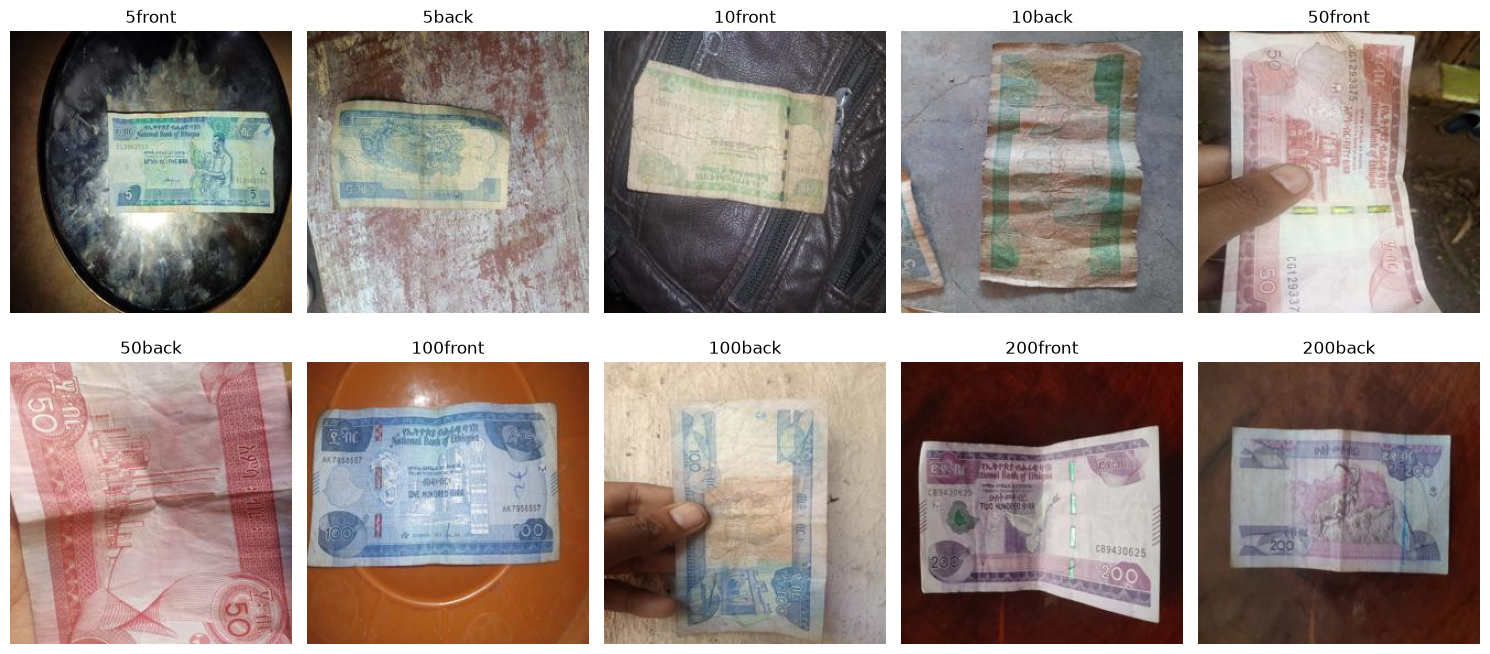

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

folders = [
    "5front",
    "5back",
    "10front",
    "10back",
    "50front",
    "50back",
    "100front",
    "100back",
    "200front",
    "200back"
]

for ax, folder in zip(axes.flatten(), folders):
    folder_path = os.path.join(TRAIN_DIR, folder)

    images = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    image_path = os.path.join(folder_path, images[0])
    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(folder)
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Label Mapping

In [24]:
CLASS_MAPPING = {
    "5front": 0,
    "5back": 0,

    "10front": 1,
    "10back": 1,

    "50front": 2,
    "50back": 2,

    "100front": 3,
    "100back": 3,

    "200front": 4,
    "200back": 4
}

CLASS_NAMES = [
    "5 Birr",
    "10 Birr",
    "50 Birr",
    "100 Birr",
    "200 Birr"
]

#### Choose Image Size

In [25]:
IMG_SIZE = (224, 224)

#### Load the images

In [26]:
def load_images(directory, class_mapping):
    images = []
    labels = []

    for folder in os.listdir(directory):

        folder_path = os.path.join(directory, folder)

        if not os.path.isdir(folder_path):
            continue

        # Skip background images
        if folder == "background":
            continue

        # Get the label from our mapping
        label = class_mapping[folder]

        for filename in os.listdir(folder_path):

            if filename.lower().endswith((".jpg", ".jpeg", ".png")):

                image_path = os.path.join(folder_path, filename)

                try:
                    image = Image.open(image_path).convert("RGB")
                    image = image.resize(IMG_SIZE)

                    images.append(np.array(image))
                    labels.append(label)

                except Exception as e:
                    print(f"Could not load {image_path}: {e}")

    return np.array(images), np.array(labels)

#### Load Training and Testing Dataset

In [27]:
X_train, y_train = load_images(TRAIN_DIR, CLASS_MAPPING)
X_test, y_test = load_images(TEST_DIR, CLASS_MAPPING)

In [28]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1480, 224, 224, 3)
y_train shape: (1480,)
X_test shape: (360, 224, 224, 3)
y_test shape: (360,)


#### Normalize the images

In [29]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [30]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


#### Class Distribution

In [31]:
# Training Set
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{CLASS_NAMES[label]}: {count}")

5 Birr: 296
10 Birr: 296
50 Birr: 296
100 Birr: 296
200 Birr: 296


In [32]:
# Testing Set
unique, counts = np.unique(y_test, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{CLASS_NAMES[label]}: {count}")

5 Birr: 72
10 Birr: 72
50 Birr: 72
100 Birr: 72
200 Birr: 72


- Both the training and testing sets are balanced.

#### Create a validation set

In [33]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [34]:
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (1184, 224, 224, 3) (1184,)
Validation: (296, 224, 224, 3) (296,)
Testing: (360, 224, 224, 3) (360,)
